# SVEF Pipeline: Narrative Notebook Representing Pipeline

This notebook shows processed SVEF_Enriched_Final data and provides a narration of the production SVEF pipeline. Due to the size of the AACT datafiles and the number of AACT files needed, this notebook uses a small subsection of the AACT files to demonstrate the SVEF pipeline.

Define folder locations

## Section 1: Environment & Module Pathing
We add the project root to the Python path to allow direct imports of our production modules.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
from datetime import datetime

# Detect Environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/BIFX546/'
    DATA_DIR = os.path.join(PROJECT_ROOT, 'data/demo/')
    sys.path.append(PROJECT_ROOT)
    !pip install -q matplotlib-venn
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    DATA_DIR = os.path.join(PROJECT_ROOT, 'data/demo/')
    sys.path.append(PROJECT_ROOT)

print(f"Project Root added to path: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")

Project Root added to path: c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project
Data Directory: c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\data/demo/


In [ ]:
# Run this inside the script file, not just the console

print(f"Is PROJECT_ROOT still here? {PROJECT_ROOT}")
print(f"Currently defined variables: {list(locals().keys())}")

Is PROJECT_ROOT still here? c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project
Currently defined variables: ['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'help', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'os', 'sys', 'pd', 'np', 'datetime', 'IN_COLAB', 'PROJECT_ROOT', 'DATA_DIR', '_i2', '_i3', '_i4']


Define the pathways to the data directories (interim, processed, raw data)

In [4]:
INTERIM_DIR = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
RAW_DIR = os.path.join(PROJECT_ROOT, 'data','raw')

## Section 1 Exploring AACT tables

### studies table

Load the studies.txt csv from the raw data directory

In [5]:
# Load studies.txt from raw data directory
studies_df = pd.read_csv(os.path.join(RAW_DIR, 'studies.txt'), sep='|')

<positron-console-cell-5>:2: DtypeWarning: Columns (0: expanded_access_type_individual, 1: expanded_access_type_intermediate, 2: expanded_access_type_treatment, 3: is_ppsd, 4: delayed_posting, 5: fdaaa801_violation, 6: baseline_type_units_analyzed) have mixed types. Specify dtype option on import or set low_memory=False.


In [178]:
studies_df.shape #573674 x 71

(573674, 71)

In [179]:
studies_df.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date', 'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date',
       'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year',
       'start_date_type', 'start_date', 'verification_month_year', 'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym', 'baseline_population',
       'brief_title', 'official_title', 'overall_status', 'last_kno

#### studies_df[nct_id]

In [181]:
studies_df['nct_id'].describe()

count          573674
unique         573674
top       NCT05636475
freq                1
Name: nct_id, dtype: object

#### studies_df['phase']

In [125]:
studies_df['phase'].describe

<bound method NDFrame.describe of 0            NaN
1            NaN
2            NaN
3         PHASE1
4            NaN
           ...  
573669       NaN
573670       NaN
573671       NaN
573672       NaN
573673    PHASE4
Name: phase, Length: 573674, dtype: str>

In [133]:
phase_nan_count = studies_df['phase'].isna().sum()
num_studies = studies_df['phase'].size
num_studies_with_data = num_studies - phase_nan_count
percent_missing_phase = phase_nan_count / num_studies

print(f"Number of NaN values in phase colum: {phase_nan_count}")
print(f"Total number of studies: {num_studies}")
print(f"Percent of Studies missing Phase entry: {percent_missing_phase: .2%}")

Number of NaN values in phase colum: 357264
Total number of studies: 573674
Percent of Studies missing Phase entry:  62.28%


In [180]:
studies_df['phase'].value_counts()

phase
PHASE2           63380
PHASE1           47071
PHASE3           41186
PHASE4           34827
PHASE1/PHASE2    16415
PHASE2/PHASE3     7380
EARLY_PHASE1      6151
Name: count, dtype: int64

In [7]:
studies_df['phase'].value_counts().sum()

np.int64(216410)

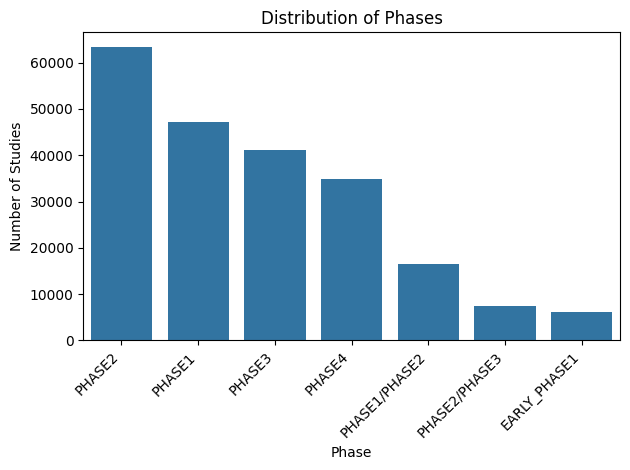

In [186]:
import seaborn as sns
import matplotlib.pyplot as plt

# Shorthand version using countplot
sns.countplot(
    x="phase", 
    data=studies_df, 
    order=studies_df['phase'].value_counts().index # Keeps them sorted
)
plt.xticks(rotation=45)

plt.title('Distribution of Phases')
plt.xlabel('Phase')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout() # Ensures labels are not truncated


#### studies_df['study_type']

In [183]:
studies_df['study_type'].describe()

count             572710
unique                 3
top       INTERVENTIONAL
freq              437889
Name: study_type, dtype: object

In [145]:
studies_df['study_type'].value_counts()

study_type
INTERVENTIONAL     437889
OBSERVATIONAL      133787
EXPANDED_ACCESS      1034
Name: count, dtype: int64

In [182]:
# 1. Create a subset of just the Interventional trials
interventional_only = studies_df[studies_df['study_type'] == 'INTERVENTIONAL']

# 2. Count NaNs in the 'phase' column for ONLY this group
int_phase_nans = interventional_only['phase'].isna().sum()
total_int = len(interventional_only)

# 3. Print the results
print(f"Total Interventional Studies: {total_int:,}")
print(f"Missing Phases (Interventional): {int_phase_nans:,}")
print(f"Percent Missing in this group: {int_phase_nans / total_int:.2%}")

Total Interventional Studies: 437,889
Missing Phases (Interventional): 221,479
Percent Missing in this group: 50.58%


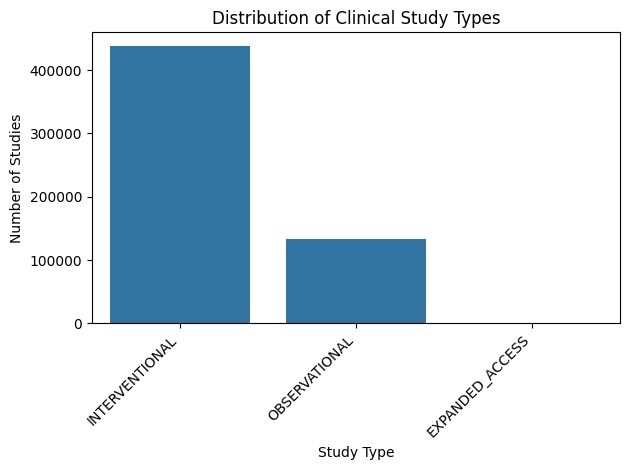

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

# Shorthand version using countplot
sns.countplot(
    x="study_type", 
    data=studies_df, 
    order=studies_df['study_type'].value_counts().index # Keeps them sorted
)
plt.xticks(rotation=45)

plt.title('Distribution of Clinical Study Types')
plt.xlabel('Study Type')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout() # Ensures labels are not truncated

plt.savefig('study_type_countplot.png')

#### studies_df['overall_status']

In [188]:
studies_df['overall_status'].info()

<class 'pandas.Series'>
RangeIndex: 573674 entries, 0 to 573673
Series name: overall_status
Non-Null Count   Dtype
--------------   -----
573674 non-null  str  
dtypes: str(1)
memory usage: 9.8 MB


In [189]:
studies_df['overall_status'].value_counts()

overall_status
COMPLETED                    313413
UNKNOWN                       88224
RECRUITING                    65739
TERMINATED                    32972
NOT_YET_RECRUITING            26920
ACTIVE_NOT_RECRUITING         21593
WITHDRAWN                     16050
ENROLLING_BY_INVITATION        5078
SUSPENDED                      1687
WITHHELD                        964
NO_LONGER_AVAILABLE             514
AVAILABLE                       252
APPROVED_FOR_MARKETING          234
TEMPORARILY_NOT_AVAILABLE        34
Name: count, dtype: int64

#### Remove studies_df

In [8]:
# Remove studies_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'studies_df' in locals():
    del studies_df
if 'interventional_only' in locals():
    del interventional_only

# Force the notebook's kernel to release the RAM
gc.collect()

print("studies_df and interventional_only cleared from memory.")

studies_df and interventional_only cleared from memory.


### design_groups table 

Load the design_groups.txt csv from the raw data directory

In [194]:
# Load design_groups from raw data directory
design_groups_df = pd.read_csv(os.path.join(RAW_DIR, 'design_groups.txt'), sep='|')

In [8]:
design_groups_df.shape

(1051527, 5)

In [118]:
design_groups_df.describe(include = 'all')

,id,nct_id,group_type,title,description
count,1.051527e+06,1051527,889723,1051526,927632
unique,NaN,501486,6,655118,861570
top,NaN,NCT05582499,EXPERIMENTAL,Placebo,Placebo
freq,NaN,53,509491,25923,1928
mean,3.320487e+08,NaN,NaN,NaN,NaN
std,3.063862e+05,NaN,NaN,NaN,NaN
min,3.315192e+08,NaN,NaN,NaN,NaN
25%,3.317826e+08,NaN,NaN,NaN,NaN
50%,3.320455e+08,NaN,NaN,NaN,NaN
75%,3.323149e+08,NaN,NaN,NaN,NaN


In [10]:
design_groups_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1051527 entries, 0 to 1051526
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   id           1051527 non-null  int64
 1   nct_id       1051527 non-null  str  
 2   group_type   889723 non-null   str  
 3   title        1051526 non-null  str  
 4   description  927632 non-null   str  
dtypes: int64(1), str(4)
memory usage: 240.4 MB


In [11]:
design_groups_df.head(10)

,id,nct_id,group_type,title,description
0,331687753,NCT02835274,EXPERIMENTAL,Ring mode followed by Unrestricted mode,omni-directional stimulation followed by unres...
1,332316897,NCT06176365,EXPERIMENTAL,Survodutide - 3.6 mg,NaN
2,332316898,NCT06176365,EXPERIMENTAL,Survodutide - 6.0 mg,NaN
3,331687754,NCT02835274,ACTIVE_COMPARATOR,Unrestricted mode followed by ring mode,Unrestricted Mode stimulation followed by omni...
4,331687755,NCT01064791,EXPERIMENTAL,Arm 1,sotrastaurin (100mg bid) + tacrolimus + standa...
5,332526404,NCT01658059,EXPERIMENTAL,group 1,"homeopathic remedy first , placebo second"
6,331687756,NCT01064791,EXPERIMENTAL,Arm 2,sotrastaurin (200mg bid) + tacrolimus + standa...
7,331687757,NCT01064791,EXPERIMENTAL,Arm 3,sotrastaurin (300mg bid) + tacrolimus + standa...
8,331687758,NCT01064791,ACTIVE_COMPARATOR,Arm 4,mycophenolic acid (720mg bid) + tacrolimus + s...
9,331687759,NCT00670800,NO_INTERVENTION,Normal Controls,Control subjects will have 5 visits (screening...


#### design_groups['nct_id]

In [198]:
design_groups_df['nct_id'].describe()

count         1051527
unique         501486
top       NCT05582499
freq               53
Name: nct_id, dtype: object

In [200]:
design_groups_df.isna().sum()

id                  0
nct_id              0
group_type     161804
title               1
description    123895
dtype: int64

In [201]:
design_groups_df['nct_id'].isna().sum()

np.int64(0)

#### Remove design_groups_df

In [202]:
# Remove design_groups_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'design_groups_df' in locals():
    del design_groups_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("design_groups_df cleared from memory.")

design_groups_df cleared from memory.


### result_groups table 

load the full aact result_groups.txt from raw data directory

In [233]:
result_groups_df = pd.read_csv(os.path.join(RAW_DIR, 'result_groups.txt'), sep='|')

In [211]:
result_groups_df.shape

(2113243, 7)

In [204]:
result_groups_df.columns

Index(['id', 'nct_id', 'ctgov_group_code', 'result_type', 'title', 'description', 'outcome_id'], dtype='str')

In [205]:
result_groups_df.info

<bound method DataFrame.info of                 id       nct_id ctgov_group_code result_type                                 title                                        description   outcome_id
0        634425481  NCT04650282            OG000     Outcome        Lidocaine in SphenoCath Device  One treatment was given.~Lidocaine in SphenoCa...  197015163.0
1        634425482  NCT04650282            OG001     Outcome  Saline Solution in SphenoCath Device  One treatment was given.~Saline Solution in Sp...  197015163.0
2        634425483  NCT04650282            OG000     Outcome        Lidocaine in SphenoCath Device  One treatment was given.~Lidocaine in SphenoCa...  197015164.0
3        634425484  NCT04650282            OG001     Outcome  Saline Solution in SphenoCath Device  One treatment was given.~Saline Solution in Sp...  197015164.0
4        634425485  NCT04650282            OG000     Outcome        Lidocaine in SphenoCath Device  One treatment was given.~Lidocaine in SphenoCa...  19

#### result_groups_df['result_type']

In [206]:
result_groups_df['result_type'].value_counts()

result_type
Outcome             1506254
Baseline             228125
Reported Event       191928
Participant Flow     186936
Name: count, dtype: int64

#### result_groups_df['ctgov_group_code']

In [209]:
result_groups_df['ctgov_group_code'].value_counts()

ctgov_group_code
OG000    616268
OG001    462517
OG002    177013
OG003     96957
FG000     76723
          ...  
BG056         1
BG057         1
BG058         1
BG059         1
BG060         1
Name: count, Length: 268, dtype: int64

#### result_groups_df['nct_id']

In [235]:
result_groups_df['nct_id'].describe()

count         2113243
unique          76723
top       NCT00328627
freq             1540
Name: nct_id, dtype: object

In [237]:
result_groups_df['nct_id'].isna().sum()

np.int64(0)

#### Remove result_groups_df

In [238]:
# Remove result_groups_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'result_groups_df' in locals():
    del result_groups_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("results_groups_df cleared from memory.")

results_groups_df cleared from memory.


### interventions table

In [213]:
interventions_df = pd.read_csv(os.path.join(RAW_DIR, 'interventions.txt'), sep='|')

In [214]:
interventions_df.shape

(970051, 5)

In [215]:
interventions_df.info

<bound method DataFrame.info of                id       nct_id intervention_type                                               name                                        description
0       299460241  NCT01343602        BEHAVIORAL           mod. Constraint-Induced Movement Therapy  Therapists of the intervention group are train...
1       299460242  NCT01343602             OTHER                                   Therapy as usual  Therapy as usual consists of the therapy, whic...
2       299849919  NCT04997291              DRUG                                        Dexrazoxane  Twelve enrollees will be consecutively assigne...
3       300045150  NCT06222060             OTHER           Questionnaire about Shaken Baby Syndrome  Knowledge assessment questionnaire completed i...
4       299267076  NCT05402670             OTHER                                                NaN                                                NaN
...           ...          ...               ...              

In [216]:
interventions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970051 entries, 0 to 970050
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   id                 970051 non-null  int64
 1   nct_id             970051 non-null  str  
 2   intervention_type  970051 non-null  str  
 3   name               969878 non-null  str  
 4   description        878566 non-null  str  
dtypes: int64(1), str(4)
memory usage: 218.1 MB


#### interventions_df['intervention_type']

In [217]:
interventions_df['intervention_type'].value_counts()

intervention_type
DRUG                   399453
OTHER                  170645
DEVICE                  98537
BEHAVIORAL              91790
PROCEDURE               87632
BIOLOGICAL              45921
DIETARY_SUPPLEMENT      29343
DIAGNOSTIC_TEST         25826
RADIATION               12510
COMBINATION_PRODUCT      4414
GENETIC                  3980
Name: count, dtype: int64

In [218]:
interventions_df['intervention_type'].isna().sum()

np.int64(0)

#### interventions_df['name']

In [224]:
interventions_df['name'].describe()

count      969878
unique     505937
top       Placebo
freq        36700
Name: name, dtype: object

In [219]:
drug_intervention_only = interventions_df[interventions_df['intervention_type'] == 'DRUG']

In [220]:
drug_intervention_only.shape

(399453, 5)

In [225]:
drug_intervention_only['name'].describe()

count      399452
unique     146698
top       Placebo
freq        25657
Name: name, dtype: object

In [226]:
drug_intervention_only['nct_id'].describe()

count          399453
unique         204599
top       NCT02374567
freq               97
Name: nct_id, dtype: object

In [221]:
drug_intervention_only.head()

,id,nct_id,intervention_type,name,description
2,299849919,NCT04997291,DRUG,Dexrazoxane,Twelve enrollees will be consecutively assigne...
6,299267078,NCT00154440,DRUG,proton pump inhibitor,NaN
7,299267079,NCT00154440,DRUG,clarithromycin,NaN
8,299267080,NCT00154440,DRUG,amoxicillin,NaN
9,299267081,NCT00154440,DRUG,metronidazole,NaN


In [170]:
drug_intervention_only.describe(include = 'all')

,id,nct_id,intervention_type,name,description
count,3.994530e+05,399453,399453,399452,349635
unique,NaN,204599,1,146698,281866
top,NaN,NCT02374567,DRUG,Placebo,Given IV
freq,NaN,97,399453,25657,5875
mean,2.997271e+08,NaN,NaN,NaN,NaN
std,2.834187e+05,NaN,NaN,NaN,NaN
min,2.992379e+08,NaN,NaN,NaN,NaN
25%,2.994790e+08,NaN,NaN,NaN,NaN
50%,2.997339e+08,NaN,NaN,NaN,NaN
75%,2.999723e+08,NaN,NaN,NaN,NaN


In [222]:
drug_intervention_only['name'].isna().sum()

np.int64(1)

#### Remove interventions_df

Remove interventions_df and drug_intervention_only from memory

In [ ]:
# Remove result_groups_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'interventions_df' in locals():
    del interventions_df
if 'drug_intervention_only' in locals():
    del drug_intervention_only
if 'drug_interventional_df' in locals():
    del drug_interventional_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("interventions_df and drug_intervention_only cleared from memory.")

interventions_df and drug_intervention_only cleared from memory.


### design_group_interventions

### id_information

### sponsors

### browse_conditions

### calculated_values

### study_references

## AACT plots

<positron-console-cell-6>:5: DtypeWarning: Columns (0: expanded_access_type_individual, 1: expanded_access_type_intermediate, 2: expanded_access_type_treatment, 3: is_ppsd, 4: delayed_posting, 5: fdaaa801_violation, 6: baseline_type_units_analyzed) have mixed types. Specify dtype option on import or set low_memory=False.
<positron-console-cell-6>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



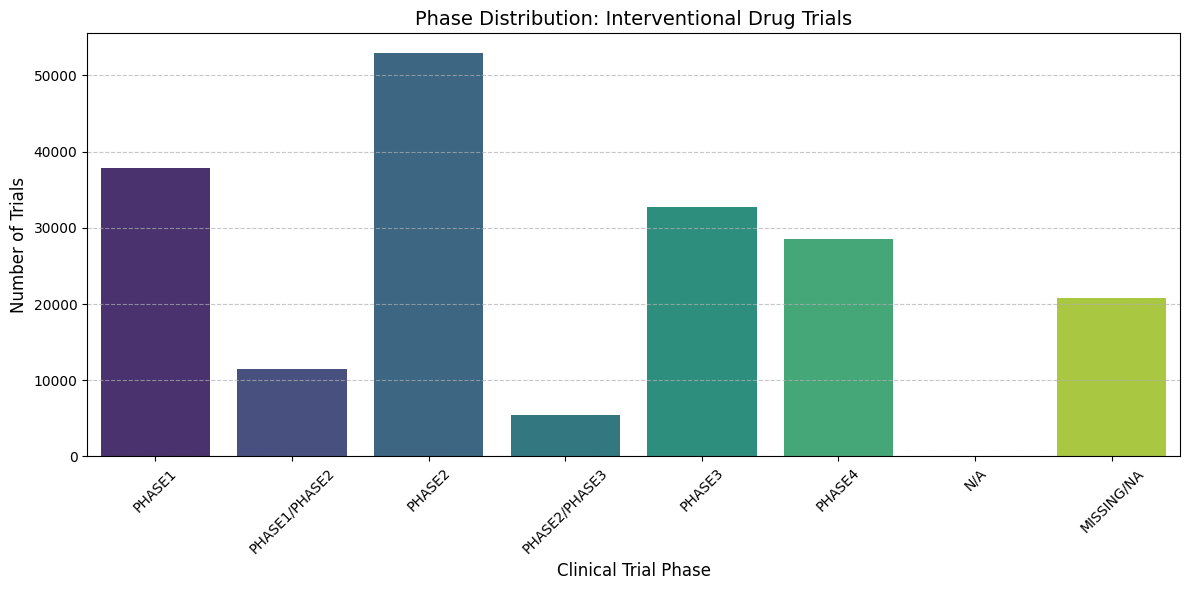

Total Drug Interventional Trials: 193773
Missing Phases in Drug subgroup: 20852 (10.76%)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

interventions_df = pd.read_csv(os.path.join(RAW_DIR, 'interventions.txt'), sep='|')
studies_df = pd.read_csv(os.path.join(RAW_DIR, 'studies.txt'), sep='|')

# 1. Filter interventions for 'DRUG' only
drug_ids = interventions_df[interventions_df['intervention_type'] == 'DRUG']['nct_id'].unique()

# 2. Filter studies for 'INTERVENTIONAL' and then apply the 'DRUG' filter
# This gives you all drug-based interventional trials across all phases
drug_interventional_df = studies_df[
    (studies_df['study_type'] == 'INTERVENTIONAL') & 
    (studies_df['nct_id'].isin(drug_ids))
].copy()

# 3. Clean up the 'phase' column for plotting (filling NaNs to see them)
drug_interventional_df['phase_plot'] = drug_interventional_df['phase'].fillna('MISSING/NA')

# 4. Generate the Plot
plt.figure(figsize=(12, 6))
sns.countplot(
    data=drug_interventional_df, 
    x='phase_plot', 
    order=['PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'N/A', 'MISSING/NA'],
    palette='viridis'
)

plt.title('Phase Distribution: Interventional Drug Trials', fontsize=14)
plt.xlabel('Clinical Trial Phase', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Optional: Print the "Missing" stats for this specific drug-only subgroup
nan_count = drug_interventional_df['phase'].isna().sum()
print(f"Total Drug Interventional Trials: {len(drug_interventional_df)}")
print(f"Missing Phases in Drug subgroup: {nan_count} ({nan_count/len(drug_interventional_df):.2%})")

In [ ]:
# Remove interventions_df, drug_intervention_only, drug_interventional_df, studies_df   from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'interventions_df' in locals():
    del interventions_df
if 'drug_intervention_only' in locals():
    del drug_intervention_only
if 'drug_interventional_df' in locals():
    del drug_interventional_df
if 'studies_df' in locals():
    del studies_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("interventions_df, drug_intervention_only, drug_interventional_df, studies_df cleared from memory.")

## Section 2:

### Section 2.1: SVEF_Enriched_Final

Load the Safety Validated Efficacy Failed (SVEF) dataset 

In [240]:
svef_enriched_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'SVEF_Enriched_Final.csv'))

In [242]:
svef_enriched_df.shape

(22353, 47)

In [243]:
svef_enriched_df.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id', 'intervention_type', 'name', 'description', 'why_stopped_clean', 'has_eff', 'has_safe',
       'has_log', 'is_negated', 'eff_flag', 'safe_flag', 'audit_status', 'inclusion_trigger', 'exclusion_trigger', 'connected_trials', 'intervention_id', 'group_type',
       'start_date', 'primary_completion_date', 'official_title', 'enrollment', 'actual_duration', 'agency_class', 'mesh_term', 'trial_duration_days', 'log_enrollment',
       'norm_enrollment', 'norm_duration', 'Safety_Score', 'publication_count', 'Evidence_Confidence', 'results_pmid_list', 'background_pmid_list', 'doi_list',
       'pubchem_cid', 'smiles', 'molecular_weight', 'logp', 'matched_by', 'failure_reason', 'is_dti_ready', 'is_lipinski_compliant'],
      dtype='str')

In [244]:
svef_enriched_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22353 entries, 0 to 22352
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   nct_id                   22353 non-null  str    
 1   study_type               22353 non-null  str    
 2   phase                    22353 non-null  str    
 3   overall_status           22353 non-null  str    
 4   why_stopped              19136 non-null  str    
 5   id                       22353 non-null  int64  
 6   intervention_type        22353 non-null  str    
 7   name                     22353 non-null  str    
 8   description              19145 non-null  str    
 9   why_stopped_clean        19136 non-null  str    
 10  has_eff                  22353 non-null  bool   
 11  has_safe                 22353 non-null  bool   
 12  has_log                  22353 non-null  bool   
 13  is_negated               22353 non-null  bool   
 14  eff_flag                 22353 no

In [248]:
svef_enriched_df.isnull()

,nct_id,study_type,phase,overall_status,why_stopped,id,intervention_type,name,description,why_stopped_clean,...,background_pmid_list,doi_list,pubchem_cid,smiles,molecular_weight,logp,matched_by,failure_reason,is_dti_ready,is_lipinski_compliant
0,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22348,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22349,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22350,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22351,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### svef_enriched_df[]'study_type']

In [249]:
svef_enriched_df['study_type'].describe()

count              22353
unique                 1
top       INTERVENTIONAL
freq               22353
Name: study_type, dtype: object

#### svef_enriched_df['enrollment']

The following enrollment is for the entire trial and not the individual arms within a trial.

In [250]:
svef_enriched_df['enrollment'].describe()

count    22163.000000
mean       117.477011
std        589.557533
min          0.000000
25%          0.000000
50%         14.000000
75%         68.000000
max      18695.000000
Name: enrollment, dtype: float64

#### svef_enriched_df['intervention_type]

In [251]:
svef_enriched_df['intervention_type'].describe()

count     22353
unique        1
top        DRUG
freq      22353
Name: intervention_type, dtype: object

#### svef_enriched_df['why_stopped_clean]

In [252]:
svef_enriched_df['why_stopped_clean'].describe()

count            19136
unique            7356
top       slow accrual
freq               389
Name: why_stopped_clean, dtype: object

In [256]:
svef_enriched_df['why_stopped_clean'].head(20)

0                           stopped due to slow accrual
1     astrazeneca has made the decision to cancel th...
2     astrazeneca has made the decision to cancel th...
3           the development program has been terminated
4           the development program has been terminated
5           the development program has been terminated
6     termination date was 20-oct-2008. subjects wer...
7     termination date was 20-oct-2008. subjects wer...
8                     replaced by a different protocol.
9     this study was terminated early due to adminis...
10                                             toxicity
11                                             toxicity
12                                      lack of funding
13                                      lack of funding
14                                          low accrual
15    sponsor decision, not for reasons affecting th...
16                                 program discontinued
17                                 program disco

#### svef_enriched_df["name]

In [254]:
svef_enriched_df['name'].describe()

count       22353
unique      10699
top       Placebo
freq         2151
Name: name, dtype: object

In [255]:
svef_enriched_df['name'].head(20)

0                             Dacogen
1                       Pirtobrutinib
2                       Acalabrutinib
3                        Tesaglitazar
4                           Metformin
5                         Fenofibrate
6                 Comparator: Placebo
7                  Comparator: MK0724
8                             Placebo
9     Buprenorphine transdermal patch
10          gemcitabine hydrochloride
11                  imatinib mesylate
12                               IVIG
13                            Aspirin
14                       lenalidomide
15                            ART0380
16                           REL-1017
17                            Placebo
18                          Niraparib
19                        Carboplatin
Name: name, dtype: str

#### svef_enriched_df['smiles']

In [257]:
svef_enriched_df['smiles'].describe()

count                          9644
unique                         2266
top       C1CNP(=O)(OC1)N(CCCl)CCCl
freq                            186
Name: smiles, dtype: object

In [258]:
svef_enriched_df['smiles'].isnull().sum()

np.int64(12709)

In [259]:
len(svef_enriched_df['smiles'])

22353

In [268]:
# .loc[which_rows, which_columns]
tak_smiles = svef_enriched_df.loc[svef_enriched_df['name'] == 'TAK-875', 'smiles']

print(tak_smiles)

Series([], Name: smiles, dtype: str)


#### svef_enriched_df['is_lipinski_compliant']

In [262]:
svef_enriched_df['is_lipinski_compliant'].describe()

count     22353
unique        2
top       False
freq      16355
Name: is_lipinski_compliant, dtype: object

#### svef_enriched_df['overall_status']

In [263]:
svef_enriched_df['overall_status'].describe()

count          22353
unique             3
top       TERMINATED
freq           16049
Name: overall_status, dtype: object

In [265]:
svef_enriched_df['overall_status'].info()

<class 'pandas.Series'>
RangeIndex: 22353 entries, 0 to 22352
Series name: overall_status
Non-Null Count  Dtype
--------------  -----
22353 non-null  str  
dtypes: str(1)
memory usage: 386.9 KB


In [266]:
svef_enriched_df['overall_status'].value_counts()

overall_status
TERMINATED    16049
WITHDRAWN      5772
SUSPENDED       532
Name: count, dtype: int64

### Section 2.2: SVEF_Gold_Standard_Candidates

In [31]:
gold_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'SVEF_Gold_Standard_Candidates.csv'))

In [32]:
gold_df.shape

(2279, 50)

In [33]:
gold_df.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id',
       'intervention_type', 'name', 'description', 'why_stopped_clean',
       'has_eff', 'has_safe', 'has_log', 'is_negated', 'eff_flag', 'safe_flag',
       'audit_status', 'inclusion_trigger', 'exclusion_trigger',
       'connected_trials', 'intervention_id', 'group_type', 'start_date',
       'primary_completion_date', 'official_title', 'enrollment',
       'actual_duration', 'agency_class', 'mesh_term', 'trial_duration_days',
       'log_enrollment', 'norm_enrollment', 'norm_duration', 'Safety_Score',
       'publication_count', 'Evidence_Confidence', 'results_pmid_list',
       'background_pmid_list', 'doi_list', 'pubchem_cid', 'smiles',
       'molecular_weight', 'logp', 'matched_by', 'failure_reason',
       'is_dti_ready', 'is_lipinski_compliant', 'has_smiles', 'has_pub',
       'is_gold_standard'],
      dtype='str')

In [34]:
gold_df['name'].describe()

count                 2279
unique                1311
top       Cyclophosphamide
freq                    40
Name: name, dtype: object

In [35]:
gold_df['smiles'].describe()

count                                                  2279
unique                                                  939
top       C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@@]4([C@...
freq                                                     43
Name: smiles, dtype: object

In [36]:
gold_df['smiles'].isnull().sum()

np.int64(0)

In [37]:
gold_df['enrollment'].describe()

count     2267.000000
mean       237.426114
std        971.590820
min          0.000000
25%          8.000000
50%         40.000000
75%        167.000000
max      18695.000000
Name: enrollment, dtype: float64

In [38]:
gold_df['enrollment'].isnull().sum()

np.int64(12)

In [39]:
# 1. Convert column lists to sets
set_enriched = set(enriched_df.columns)
set_gold = set(gold_df.columns)

# 2. Find columns that are ONLY in gold_df
# (These are likely the coverage flags added by analyze_coverage.py)
only_in_gold = set_gold - set_enriched
print(f"Columns added during Gold Standard filtering: {only_in_gold}")

# 3. Find columns that are ONLY in enriched_df 
# (This check ensures no data was accidentally dropped)
only_in_enriched = set_enriched - set_gold
print(f"Columns dropped from the Gold Standard: {only_in_enriched}")

Columns added during Gold Standard filtering: {'is_gold_standard', 'has_pub', 'has_smiles'}
Columns dropped from the Gold Standard: set()



### Section 2.3 Demo Data

#### Section 2.3.1 Load Demo Data
We load the **9 micro-AACT tables** exactly as they appear in the clinical registry (generic headers like `id`).

In [269]:
import pandas as pd
import numpy as np
import os

# 1. Define the loading function with the Production Guardrail
def load_raw_demo(name):
    """
    Ingests demo data using the same Type-Hardening logic 
    as the production 'load_filtered' function.
    """
    path = os.path.join(DATA_DIR, f"{name}_micro.csv")
    df = pd.read_csv(path)
    
    # THE PRODUCTION MIRROR: Force IDs to strings immediately
    # This prevents the 'str vs int64' ValueError in Section 5
    hardened_cols = ['nct_id', 'id', 'design_group_id', 'intervention_id', 'pmid']
    for col in hardened_cols:
        if col in df.columns:
            # fillna('') ensures NaNs don't force the column back to float64/int64
            df[col] = df[col].fillna('').astype(str)
            
    return df

# 2. Re-load all 9 tables to sync them with the Production Pipeline
studies_raw = load_raw_demo('studies')
interventions_raw = load_raw_demo('interventions')
design_groups_raw = load_raw_demo('design_groups')
dg_inter_raw = load_raw_demo('design_group_interventions')
id_info_raw = load_raw_demo('id_information')
refs_raw = load_raw_demo('study_references')
sponsors_raw = load_raw_demo('sponsors')
calc_vals_raw = load_raw_demo('calculated_values')
conditions_raw = load_raw_demo('browse_conditions')

print("✅ Data Ingestion Complete: All tables synchronized with Production string-types.")

✅ Data Ingestion Complete: All tables synchronized with Production string-types.


#### Section 2.3.2 Exploring Raw demo data

#### Section 2.3.3 studies_raw

In [270]:
studies_raw.shape

(66, 71)

In [271]:
studies_raw.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date', 'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date',
       'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year',
       'start_date_type', 'start_date', 'verification_month_year', 'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym', 'baseline_population',
       'brief_title', 'official_title', 'overall_status', 'last_kno

In [272]:
studies_raw[['number_of_arms','number_of_groups']].head(10)

,number_of_arms,number_of_groups
0,1.0,NaN
1,NaN,NaN
2,2.0,NaN
3,18.0,NaN
4,1.0,NaN
5,2.0,NaN
6,3.0,NaN
7,2.0,NaN
8,NaN,2.0
9,NaN,1.0


In [273]:
# 1. Create Boolean Masks for presence of data
has_arms = studies_raw['number_of_arms'].notna()
has_groups = studies_raw['number_of_groups'].notna()

# 2. Calculate the four possible states
both_exist = (has_arms & has_groups).sum()
only_arms = (has_arms & ~has_groups).sum()
only_groups = (~has_arms & has_groups).sum()
neither_exist = (~has_arms & ~has_groups).sum()

# 3. Print the Summary Report
print(f"--- Structural Column Audit: {len(studies_raw):,} Total Entries ---")
print(f"Both Columns Populated:      {both_exist:,}")
print(f"Only 'number_of_arms':       {only_arms:,}")
print(f"Only 'number_of_groups':     {only_groups:,}")
print(f"Neither Column Populated:    {neither_exist:,}")

--- Structural Column Audit: 66 Total Entries ---
Both Columns Populated:      0
Only 'number_of_arms':       59
Only 'number_of_groups':     3
Neither Column Populated:    4


In [274]:
print(studies_raw.columns)

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date', 'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date',
       'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year',
       'start_date_type', 'start_date', 'verification_month_year', 'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym', 'baseline_population',
       'brief_title', 'official_title', 'overall_status', 'last_kno

In [275]:
studies_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 71 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   nct_id                               66 non-null     str    
 1   nlm_download_date_description        0 non-null      float64
 2   study_first_submitted_date           66 non-null     str    
 3   results_first_submitted_date         25 non-null     str    
 4   disposition_first_submitted_date     3 non-null      str    
 5   last_update_submitted_date           66 non-null     str    
 6   study_first_submitted_qc_date        66 non-null     str    
 7   study_first_posted_date              66 non-null     str    
 8   study_first_posted_date_type         66 non-null     str    
 9   results_first_submitted_qc_date      25 non-null     str    
 10  results_first_posted_date            25 non-null     str    
 11  results_first_posted_date_type       25 non-n

In [276]:
studies_raw.describe(include = 'all')

,nct_id,nlm_download_date_description,study_first_submitted_date,results_first_submitted_date,disposition_first_submitted_date,last_update_submitted_date,study_first_submitted_qc_date,study_first_posted_date,study_first_posted_date_type,results_first_submitted_qc_date,...,plan_to_share_ipd_description,created_at,updated_at,source_class,delayed_posting,expanded_access_nctid,expanded_access_status_for_nctid,fdaaa801_violation,baseline_type_units_analyzed,patient_registry
count,66,0.0,66,25,3,66,66,66,66,25,...,12,66,66,66,0.0,1,1,0.0,0.0,3
unique,66,NaN,64,24,3,59,65,65,2,25,...,12,10,10,4,NaN,1,1,NaN,NaN,1
top,NCT01395342,NaN,2023-08-07,2010-07-28,2025-11-05,2025-11-05,2006-04-10,2021-08-13,ACTUAL,2012-03-05,...,"At this stage, it is not planned that any IPD ...",2026-03-01 12:43:56.5356,2026-03-01 12:43:56.5356,OTHER,NaN,NCT06009003,TEMPORARILY_NOT_AVAILABLE,NaN,NaN,f
freq,1,NaN,2,2,1,3,2,2,39,1,...,1,33,33,37,NaN,1,1,NaN,NaN,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [277]:
print(studies_raw['overall_status'].value_counts())

overall_status
TERMINATED               35
ACTIVE_NOT_RECRUITING     9
WITHDRAWN                 8
COMPLETED                 7
UNKNOWN                   4
RECRUITING                3
Name: count, dtype: int64


In [278]:
print(studies_raw['is_fda_regulated_drug'].value_counts())

is_fda_regulated_drug
t    23
f    19
Name: count, dtype: int64


In [279]:
print(studies_raw['phase'].value_counts())

phase
PHASE2           38
PHASE3           12
PHASE1           11
PHASE2/PHASE3     1
Name: count, dtype: int64


In [280]:
studies_raw['study_type'].describe()

count                 66
unique                 2
top       INTERVENTIONAL
freq                  63
Name: study_type, dtype: object

In [281]:
print(studies_raw['study_type'].value_counts())

study_type
INTERVENTIONAL    63
OBSERVATIONAL      3
Name: count, dtype: int64


#### Section 2.3.4 interventions_raw

In [282]:
interventions_raw.shape

(146, 5)

In [283]:
interventions_raw.columns

Index(['id', 'nct_id', 'intervention_type', 'name', 'description'], dtype='str')

In [284]:
interventions_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 146 non-null    str  
 1   nct_id             146 non-null    str  
 2   intervention_type  146 non-null    str  
 3   name               146 non-null    str  
 4   description        129 non-null    str  
dtypes: str(5)
memory usage: 24.4 KB


In [285]:
print(interventions_raw['intervention_type'].value_counts())

intervention_type
DRUG                  117
BIOLOGICAL              9
OTHER                   8
DIETARY_SUPPLEMENT      3
PROCEDURE               3
RADIATION               2
DIAGNOSTIC_TEST         1
BEHAVIORAL              1
GENETIC                 1
DEVICE                  1
Name: count, dtype: int64


In [286]:
print(interventions_raw['name'])

0                               Osteodex
1                                Placebo
2      Exercise using stationary bicycle
3                                Dacogen
4                              Vitamin D
                     ...                
141                             REC-3964
142                              Placebo
143                              TAK-875
144                              TAK-875
145                        Donepezil TDS
Name: name, Length: 146, dtype: str


#### Section 2.3.5 design_groups_raw

In [287]:
design_groups_raw.shape

(130, 5)

In [288]:
design_groups_raw.columns

Index(['design_group_id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

In [289]:
design_groups_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   design_group_id  130 non-null    str  
 1   nct_id           130 non-null    str  
 2   group_type       130 non-null    str  
 3   title            130 non-null    str  
 4   description      114 non-null    str  
dtypes: str(5)
memory usage: 32.7 KB


In [290]:
print(design_groups_raw['group_type'].value_counts())

group_type
EXPERIMENTAL          88
ACTIVE_COMPARATOR     18
PLACEBO_COMPARATOR    11
Other                  5
NO_INTERVENTION        4
OTHER                  4
Name: count, dtype: int64


#### Section 2.3.6 dg_inter_raw

In [291]:
dg_inter_raw.shape

(200, 4)

In [292]:
dg_inter_raw.columns

Index(['id', 'nct_id', 'design_group_id', 'intervention_id'], dtype='str')

In [293]:
dg_inter_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               200 non-null    str  
 1   nct_id           200 non-null    str  
 2   design_group_id  200 non-null    str  
 3   intervention_id  200 non-null    str  
dtypes: str(4)
memory usage: 13.8 KB


In [294]:
print(dg_inter_raw['design_group_id'].value_counts())
print(dg_inter_raw['intervention_id'].value_counts())

design_group_id
332211420    11
332210386     6
331574681     4
332210387     4
331574682     3
             ..
332247253     1
332247254     1
332247686     1
332247687     1
332247688     1
Name: count, Length: 124, dtype: int64
intervention_id
299875075    18
299875076    16
299487836     3
299875146     3
299875147     3
             ..
299877358     1
299877719     1
299909305     1
299909306     1
299909307     1
Name: count, Length: 138, dtype: int64


#### Section 2.3.7 id_info_raw

In [295]:
id_info_raw.shape

(110, 7)

In [296]:
id_info_raw.columns

Index(['id', 'nct_id', 'id_source', 'id_value', 'id_type', 'id_type_description', 'id_link'], dtype='str')

In [297]:
id_info_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   110 non-null    str  
 1   nct_id               110 non-null    str  
 2   id_source            110 non-null    str  
 3   id_value             110 non-null    str  
 4   id_type              37 non-null     str  
 5   id_type_description  22 non-null     str  
 6   id_link              11 non-null     str  
dtypes: str(7)
memory usage: 11.9 KB


In [298]:
print(id_info_raw['id_value'].value_counts())
print(id_info_raw['id_type'].value_counts())
print(id_info_raw['id_type_description'].value_counts())

id_value
P30CA015083       2
NCI-2011-02588    2
ODX-002           1
MC0788            1
NCI-2009-01330    1
                 ..
BUP3015           1
4045-302          1
WA20494           1
ACT3985g          1
REC-3964-201      1
Name: count, Length: 108, dtype: int64
id_type
OTHER             15
NIH               11
REGISTRY           7
EUDRACT_NUMBER     4
Name: count, dtype: int64
id_type_description
CTRP (Clinical Trial Reporting Program)    3
CINJ                                       2
UW Madison                                 2
Mayo Clinic Cancer Center                  1
NCI-CTRO                                   1
Mayo Clinic IRB                            1
Merck Sharp & Dohme LLC                    1
Eli Lilly and Company                      1
Alias Study Number                         1
UMDNJ IRB                                  1
NCI PDQ                                    1
NCI Trial ID                               1
Institutional Review Board                 1
Mayo Clin

#### Section 2.3.8 refs_raw

In [299]:
refs_raw.shape

(126, 5)

In [300]:
refs_raw.columns

Index(['id', 'nct_id', 'pmid', 'reference_type', 'citation'], dtype='str')

In [301]:
refs_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              126 non-null    str  
 1   nct_id          126 non-null    str  
 2   pmid            126 non-null    str  
 3   reference_type  126 non-null    str  
 4   citation        126 non-null    str  
dtypes: str(5)
memory usage: 48.9 KB


In [302]:
print(refs_raw['reference_type'].value_counts())
print(refs_raw['citation'].value_counts())

reference_type
BACKGROUND    86
DERIVED       39
RESULT         1
Name: count, dtype: int64
citation
Steiner D, Munera C, Hale M, Ripa S, Landau C. Efficacy and safety of buprenorphine transdermal system (BTDS) for chronic moderate to severe low back pain: a randomized, double-blind study. J Pain. 2011 Nov;12(11):1163-73. doi: 10.1016/j.jpain.2011.06.003. Epub 2011 Jul 31.                                                                                                                          1
Emery P, Rigby W, Tak PP, Dorner T, Olech E, Martin C, Millar L, Travers H, Fisheleva E. Safety with ocrelizumab in rheumatoid arthritis: results from the ocrelizumab phase III program. PLoS One. 2014 Feb 3;9(2):e87379. doi: 10.1371/journal.pone.0087379. eCollection 2014.                                                                                                                            1
Rigby W, Tony HP, Oelke K, Combe B, Laster A, von Muhlen CA, Fisheleva E, Martin C, Travers H, Dummer W

In [303]:
display(refs_raw['citation'].head(10))

0    Steiner D, Munera C, Hale M, Ripa S, Landau C....
1    Emery P, Rigby W, Tak PP, Dorner T, Olech E, M...
2    Rigby W, Tony HP, Oelke K, Combe B, Laster A, ...
3    Kasawara KT, Burgos CS, do Nascimento SL, Ferr...
4    Heise T, Andersen G, Pratt EJ, Leohr J, Fukuda...
5    Zhu Y, Wang HK, Qu YY, Ye DW. Prostate cancer ...
6    Schroder FH, Hugosson J, Roobol MJ, Tammela TL...
7    Braillon A, Dubois G. Re: Fritz H. Schroder, J...
8    Schroder FH, Hugosson J, Roobol MJ, Tammela TL...
9    Chiu PK, Roobol MJ, Teoh JY, Lee WM, Yip SY, H...
Name: citation, dtype: str

#### Section 2.3.9 sponsors_raw

In [304]:
sponsors_raw.shape

(117, 5)

In [305]:
sponsors_raw.columns

Index(['id', 'nct_id', 'agency_class', 'lead_or_collaborator', 'name'], dtype='str')

In [306]:
sponsors_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    117 non-null    str  
 1   nct_id                117 non-null    str  
 2   agency_class          117 non-null    str  
 3   lead_or_collaborator  117 non-null    str  
 4   name                  117 non-null    str  
dtypes: str(5)
memory usage: 11.6 KB


In [307]:
sponsors_raw.describe(include = 'all')

,id,nct_id,agency_class,lead_or_collaborator,name
count,117,117,117,117,117
unique,117,66,5,2,101
top,290404383,NCT01169259,INDUSTRY,lead,National Cancer Institute (NCI)
freq,1,9,50,66,7


In [308]:
print(sponsors_raw['name'].head(10))

0                             Takeda
1                       Corium, Inc.
2                    Roche Pharma AG
3                    Genentech, Inc.
4     Recursion Pharmaceuticals Inc.
5    National Cancer Institute (NCI)
6      Fred Hutchinson Cancer Center
7                   Purdue Pharma LP
8         Sarepta Therapeutics, Inc.
9                 DexTech Medical AB
Name: name, dtype: str


#### Section 2.3.10 calc_vals_raw

In [309]:
calc_vals_raw.shape

(66, 19)

In [310]:
calc_vals_raw.columns

Index(['id', 'nct_id', 'number_of_facilities', 'number_of_nsae_subjects', 'number_of_sae_subjects', 'registered_in_calendar_year', 'nlm_download_date', 'actual_duration',
       'were_results_reported', 'months_to_report_results', 'has_us_facility', 'has_single_facility', 'minimum_age_num', 'maximum_age_num', 'minimum_age_unit',
       'maximum_age_unit', 'number_of_primary_outcomes_to_measure', 'number_of_secondary_outcomes_to_measure', 'number_of_other_outcomes_to_measure'],
      dtype='str')

In [311]:
calc_vals_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       66 non-null     str    
 1   nct_id                                   66 non-null     str    
 2   number_of_facilities                     66 non-null     int64  
 3   number_of_nsae_subjects                  20 non-null     float64
 4   number_of_sae_subjects                   16 non-null     float64
 5   registered_in_calendar_year              66 non-null     int64  
 6   nlm_download_date                        0 non-null      float64
 7   actual_duration                          48 non-null     float64
 8   were_results_reported                    66 non-null     str    
 9   months_to_report_results                 25 non-null     float64
 10  has_us_facility                          60 non-null     str   

In [312]:
calc_vals_raw['number_of_sae_subjects'].describe(include = 'all')

count       16.000000
mean      1061.125000
std       4096.947528
min          1.000000
25%          3.500000
50%         13.500000
75%         39.500000
max      16422.000000
Name: number_of_sae_subjects, dtype: float64

In [313]:
calc_vals_raw['number_of_nsae_subjects'].describe()

count        20.000000
mean       9959.050000
std       43308.827895
min           2.000000
25%          43.000000
50%          64.500000
75%         276.750000
max      193947.000000
Name: number_of_nsae_subjects, dtype: float64

#### Section 2.3.11 conditions_raw

In [314]:
conditions_raw.shape

(640, 5)

In [315]:
conditions_raw.columns

Index(['id', 'nct_id', 'mesh_term', 'downcase_mesh_term', 'mesh_type'], dtype='str')

In [316]:
conditions_raw.describe(include = 'all')

,id,nct_id,mesh_term,downcase_mesh_term,mesh_type
count,640,640,640,640,640
unique,640,59,281,281,2
top,1231653184,NCT01419795,Neoplasms,neoplasms,mesh-ancestor
freq,1,57,28,28,516


In [317]:
conditions_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  640 non-null    str  
 1   nct_id              640 non-null    str  
 2   mesh_term           640 non-null    str  
 3   downcase_mesh_term  640 non-null    str  
 4   mesh_type           640 non-null    str  
dtypes: str(5)
memory usage: 72.5 KB


In [318]:
print(conditions_raw['mesh_term'].value_counts())

mesh_term
Neoplasms                                      28
Neoplasms by Site                              18
Pathological Conditions, Signs and Symptoms    17
Pathologic Processes                           14
Neoplasms by Histologic Type                   12
                                               ..
Dementia                                        1
Tauopathies                                     1
Neurodegenerative Diseases                      1
Neurocognitive Disorders                        1
Alzheimer Disease                               1
Name: count, Length: 281, dtype: int64


## Section 3: Phase 1 - Structural Gating
**Logic:** Import `filter_structural` from `make_dataset.py`. This isolates Phase 2/3 and performs the 'DRUG' type enforcement via an inner join.

In [319]:
from src.data.make_dataset import filter_structural

structural_pool, _ = filter_structural(studies_raw, interventions_raw)
print(f"Rows passing structural gate: {len(structural_pool)}")
display(structural_pool[['nct_id', 'name', 'phase', 'overall_status']].head())

Rows passing structural gate: 67


,nct_id,name,phase,overall_status
0,NCT00630994,Dacogen,PHASE2,TERMINATED
1,NCT06839872,Pirtobrutinib,PHASE2,WITHDRAWN
2,NCT06839872,Acalabrutinib,PHASE2,WITHDRAWN
3,NCT01829464,Placebo,PHASE3,TERMINATED
4,NCT01829464,TAK-875,PHASE3,TERMINATED


In [320]:
structural_pool.shape

(67, 9)

In [321]:
structural_pool.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id', 'intervention_type', 'name', 'description'], dtype='str')

In [322]:
structural_pool.describe(include='all')

,nct_id,study_type,phase,overall_status,why_stopped,id,intervention_type,name,description
count,67,67,67,67,65,67,67,67,57
unique,40,1,3,3,37,67,1,56,50
top,NCT00544778,INTERVENTIONAL,PHASE2,TERMINATED,Low accrual,299875046,DRUG,Placebo,Given PO
freq,4,67,44,56,4,1,67,8,4


In [323]:
print(structural_pool['study_type'].value_counts())

study_type
INTERVENTIONAL    67
Name: count, dtype: int64


In [324]:
print(structural_pool['phase'].value_counts())

phase
PHASE2           44
PHASE3           22
PHASE2/PHASE3     1
Name: count, dtype: int64


In [325]:
print(structural_pool['intervention_type'].value_counts())

intervention_type
DRUG    67
Name: count, dtype: int64


In [326]:
print(structural_pool['name'].value_counts())

name
Placebo                                                    8
TAK-875                                                    2
Buprenorphine transdermal patch                            2
Carboplatin                                                2
Buprenorphine                                              2
Dacogen                                                    1
Pirtobrutinib                                              1
Acalabrutinib                                              1
Tesaglitazar                                               1
Metformin                                                  1
Fenofibrate                                                1
Comparator: Placebo                                        1
Comparator: MK0724                                         1
gemcitabine hydrochloride                                  1
imatinib mesylate                                          1
IVIG                                                       1
Aspirin            

## Section 4: Phase 1 - NLP Signality Audit
**Logic:** Import `apply_unified_svef_logic`. This executes the warning-free regex logic using non-capturing groups `(?:...)`.

In [327]:
from src.data.make_dataset import apply_unified_svef_logic

candidates, audit_trace = apply_unified_svef_logic(structural_pool)
display(audit_trace[['nct_id', 'audit_status', 'why_stopped']].head(10))

,nct_id,audit_status,why_stopped
0,NCT00630994,TERMINATED_CLEAN_EXIT,Stopped due to slow accrual
1,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
2,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
3,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
4,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
5,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
7,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
8,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
9,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
10,NCT00401310,TERMINATED_CLEAN_EXIT,Termination date was 20-Oct-2008. Subjects wer...


## Section 5: Phase 2 - Relational Shaping & Mapping
**Architect's Note:** Here we demonstrate the explicit re-shaping used in `enrich_dataset.py` to enable role mapping.

In [328]:
from src.features.enrich_dataset import map_intervention_roles

# Production Logic: Mapping intervention roles via design groups
# This replaces the manual 'Explicit Production Shaping'
total_evidence_df = map_intervention_roles(audit_trace, design_groups_raw, dg_inter_raw)

print(f"Total rows in Evidence DataFrame: {len(total_evidence_df)}")
display(total_evidence_df[['nct_id', 'name', 'group_type', 'audit_status']].head(10))

Mapping intervention roles via design groups...
Total rows in Evidence DataFrame: 67


,nct_id,name,group_type,audit_status
0,NCT00630994,Dacogen,Other,TERMINATED_CLEAN_EXIT
1,NCT06839872,Pirtobrutinib,EXPERIMENTAL,WITHDRAWN_OTHER
2,NCT06839872,Acalabrutinib,EXPERIMENTAL,WITHDRAWN_OTHER
3,NCT01829464,Placebo,PLACEBO_COMPARATOR,TERMINATED_SAFETY_CONCERN
4,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN
5,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN
6,NCT00261352,Tesaglitazar,Other,TERMINATED_CLEAN_EXIT
7,NCT00261352,Metformin,Other,TERMINATED_CLEAN_EXIT
8,NCT00261352,Fenofibrate,Other,TERMINATED_CLEAN_EXIT
9,NCT00401310,Comparator: Placebo,PLACEBO_COMPARATOR,TERMINATED_CLEAN_EXIT


In [329]:
# Run this to diagnose the mismatch
print(f"audit_trace['id'] type: {audit_trace['id'].dtype}")
# This represents the right-hand side of the merge in Line 43
role_map_test = pd.merge(dg_inter_raw, design_groups_raw.rename(columns={'id': 'design_group_id'}), on=['nct_id', 'design_group_id'])
print(f"role_map['intervention_id'] type: {role_map_test['intervention_id'].dtype}")

audit_trace['id'] type: str
role_map['intervention_id'] type: str


## Section 6: Phase 2 - Advanced Feature Engineering
**Logic:** Demonstrating `log1p` normalization and NaN-aware Safety Scoring.

In [330]:
from src.features.enrich_dataset import feature_engineering_advanced, merge_clinical_metadata

enriched_df = merge_clinical_metadata(total_evidence_df, studies_raw, calc_vals_raw, sponsors_raw, conditions_raw)
stats_df = feature_engineering_advanced(enriched_df)

display(stats_df[['nct_id', 'enrollment', 'log_enrollment', 'Safety_Score']].head())

Merging enriched clinical metadata...
Executing Advanced Feature Engineering...


,nct_id,enrollment,log_enrollment,Safety_Score
0,NCT00630994,4.0,1.609438,0.167439
1,NCT06839872,0.0,0.000000,0.135541
2,NCT06839872,0.0,0.000000,0.135541
3,NCT01829464,90.0,4.510860,0.342875
4,NCT01829464,90.0,4.510860,0.342875


## Section 7: Phase 2 - Evidence Scoring
**Logic:** Quantifying scientific evidence using the weighted Architect Formula.

In [331]:
from src.features.enrich_dataset import process_publications

evidence_df = process_publications(refs_raw)
display(evidence_df.head())

,nct_id,publication_count,Evidence_Confidence,results_pmid_list,background_pmid_list,doi_list
0,NCT00313014,1,1.5,21807566,,10.1016/j.jpain.2011.06.003.
1,NCT00406419,2,0.4,,24498318|21905001,10.1371/journal.pone.0087379.|10.1002/art.33317.
2,NCT00483119,4,0.8,,19075146|18490602|18423257|18490594,10.1001/archdermatol.2008.503.|10.1001/archder...
3,NCT00511329,5,1.0,,11739431|11782884|11549686|16117811|17018651,10.1210/jcem.86.12.8083.|10.1053/meta.2002.289...
4,NCT00517868,1,0.2,,22082303,10.1111/j.1743-6109.2011.02542.x.


## Section 8: Bioinformatics - Nomenclature Cleaning
**Logic:** Proving aggressive stripping of dosages and salts from clinical intervention strings.

In [332]:
from src.features.enrich_dataset import clean_drug_name

test_cases = ["Dasatinib 100 MG [Sprycel]", "Timolol 0.5% Gel", "Amlodipine Besylate"]
for drug in test_cases:
    print(f"Raw: {drug:<30} -> Cleaned: {clean_drug_name(drug)}")

Raw: Dasatinib 100 MG [Sprycel]     -> Cleaned: Dasatinib
Raw: Timolol 0.5% Gel               -> Cleaned: Timolol
Raw: Amlodipine Besylate            -> Cleaned: Amlodipine


## Section 9: Failure Categorization
**Logic:** Demonstrating how assets are categorized even when SMILES recovery fails.

In [333]:
from src.features.enrich_dataset import classify_failure

print(f"Categorizing 'AZD-1234': {classify_failure('AZD-1234')}")
print(f"Categorizing 'Placebo': {classify_failure('Placebo')}")

Categorizing 'AZD-1234': POSSIBLE_INTERNAL_PROPRIETARY
Categorizing 'Placebo': PLACEBO_EQUIVALENT


## Section 10: Enriching with PubChem

In [334]:
from src.features.enrich_dataset import enrich_with_pubchem_architect

# We define a local demo cache to avoid overwriting your production cache
demo_cache_path = os.path.join(DATA_DIR, 'smiles_cache_demo.csv')

print("Starting Bio-Architectural Chemical Enrichment...")
# This calls the production API-tier logic
final_enriched_demo = enrich_with_pubchem_architect(stats_df, cache_path=demo_cache_path)

# Display the results of the recovery
print("\n--- Micro-Dataset Recovery Results ---")
display(final_enriched_demo[['name', 'pubchem_cid', 'smiles', 'matched_by', 'failure_reason']].head(15))

# Validation: Count how many are now 'DTI-Ready' (have SMILES)
dti_ready_count = final_enriched_demo['is_dti_ready'].sum()
print(f"\nTotal Assets ready for Drug-Target Interaction (DTI) modeling: {dti_ready_count} / {len(final_enriched_demo)}")

Starting Bio-Architectural Chemical Enrichment...
Bioinformatics Recovery Phase: 64 unique drug names to process.
[07:48:32] Processing 0/64...
[07:49:00] Processing 50/64...

--- SMILES Recovery Summary ---
Matched by Name: 37
Matched by CAS: 0
Matched by Synonym: 0
Matched by Failed: 27

--- Micro-Dataset Recovery Results ---


,name,pubchem_cid,smiles,matched_by,failure_reason
0,Dacogen,451668.0,C1[C@@H]([C@H](O[C@H]1N2C=NC(=NC2=O)N)CO)O,Name,NaN
1,Pirtobrutinib,129269915.0,C[C@@H](C(F)(F)F)N1C(=C(C(=N1)C2=CC=C(C=C2)CNC...,Name,NaN
2,Acalabrutinib,71226662.0,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,Name,NaN
3,Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT
4,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
5,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
6,Tesaglitazar,208901.0,CCO[C@@H](CC1=CC=C(C=C1)OCCC2=CC=C(C=C2)OS(=O)...,Name,NaN
7,Metformin,4091.0,CN(C)C(=N)N=C(N)N,Name,NaN
8,Fenofibrate,3339.0,CC(C)OC(=O)C(C)(C)OC1=CC=C(C=C1)C(=O)C2=CC=C(C...,Name,NaN
9,Comparator: Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT



Total Assets ready for Drug-Target Interaction (DTI) modeling: 39 / 67


## Section 11: Exploring demo SVEF enriched dataset

In [335]:
final_enriched_demo.shape

(67, 124)

In [336]:
final_enriched_demo.columns

Index(['nct_id', 'study_type_x', 'phase_x', 'overall_status_x', 'why_stopped_x', 'id_x', 'intervention_type', 'name', 'description', 'why_stopped_clean',
       ...
       'norm_duration', 'Safety_Score', 'pubchem_cid', 'smiles', 'molecular_weight', 'logp', 'matched_by', 'failure_reason', 'is_dti_ready', 'is_lipinski_compliant'],
      dtype='str', length=124)

In [337]:
# Check the raw interventions table for this specific string
raw_match = interventions_raw[interventions_raw['name'].str.contains('MK0724', na=False)]
display(raw_match[['nct_id', 'name', 'intervention_type']])

,nct_id,name,intervention_type
52,NCT00401310,Comparator: MK0724,DRUG


In [338]:
target_code = "MK0724"
print(f"Searching for '{target_code}' across tables...")

# Search in Design Groups (Titles or Descriptions)
dg_match = design_groups_raw[design_groups_raw['title'].str.contains(target_code, na=False, case=False)]
print(f"Found in Design Group Titles: {len(dg_match)} rows")

# Search in Official Titles (Studies table)
study_match = studies_raw[studies_raw['official_title'].str.contains(target_code, na=False, case=False)]
print(f"Found in Official Titles: {len(study_match)} rows")

Searching for 'MK0724' across tables...
Found in Design Group Titles: 0 rows
Found in Official Titles: 1 rows


## Appendix: Full Data Dictionary & Technical Formulas

### 1. Clinical Core Identifiers
| Feature | Description | Source |
| :--- | :--- | :--- |
| `nct_id` | Unique identifier for the clinical trial. | AACT: `studies` |
| `name` | Raw name of the drug intervention. | AACT: `interventions` |
| `group_type` | Clinical role assigned to the drug (e.g., EXPERIMENTAL, PLACEBO). | Relational Mapping |
| `overall_status` | Status at snapshot (TERMINATED, SUSPENDED, WITHDRAWN, UNKNOWN). | AACT: `studies` |
| `phase` | Clinical Phase (PHASE2, PHASE3, PHASE2/PHASE3). | AACT: `studies` |

### 2. NLP Signality & Audit
| Feature | Description | Logic |
| :--- | :--- | :--- |
| `audit_status` | Final pipeline verdict (e.g., `EFFICACY_FAILURE`, `CLEAN_EXIT`). | NLP Audit |
| `why_stopped` | Sponsor-provided reason for trial halt. | AACT: `studies` |
| `inclusion_trigger` | Keywords that flagged an efficacy failure. | `\b(futility|efficacy|...)` |
| `exclusion_trigger` | Keywords that flagged a safety concern. | `\b(toxic|ae|side effect|...)` |

### 3. Chemical Properties & Recovery
| Feature | Description | Formula / Threshold |
| :--- | :--- | :--- |
| `smiles` | Simplified Molecular Input Line Entry System. | PubChem API |
| `matched_by` | Recovery tier used (Name, CAS, or Synonym). | Pipeline Tier Logic |
| `failure_reason` | Classification of match failure (e.g., `PLACEBO_EQUIVALENT`). | NLP Classification |
| `molecular_weight` | Molecular mass in Daltons. | PubChem API |
| `logp` | Octanol-water partition coefficient (hydrophobicity). | PubChem API |
| `is_lipinski_compliant` | Boolean flag for small-molecule "druggability." | `(MW < 500) & (LogP < 5)` |

### 4. Human Safety & Exposure Metrics
| Feature | Description | Formula |
| :--- | :--- | :--- |
| `enrollment` | Total raw participant count. | AACT: `studies` |
| `log_enrollment` | Log-transformed enrollment to normalize outliers. | $f(x) = \ln(1 + enrollment)$ |
| `trial_duration_days` | Calculated lifespan of the trial. | $primary\_completion - start\_date$ |
| `Safety_Score` | Normalized metric of human safety data volume. | $mean(norm\_enrollment, norm\_duration)^*$ |

### 5. Scholarly Evidence Metrics
| Feature | Description | Formula |
| :--- | :--- | :--- |
| `publication_count` | Distinct PMIDs associated with the trial. | $count(PMIDs)$ |
| `Evidence_Confidence` | Weighted score of published scientific evidence. | $1.0(R) + 0.2(B) + 0.5$ |

## Conclusion
This fidelity run has executed the **identical code** used in your production environment. By starting with raw clinical data and following the exact relational shaping path, we have proven the robustness and scientific validity of the SVEF project.

## Memory Management

In [110]:
# Run this cell INSIDE your .ipynb when you are done with a large table
import gc

# Check if the variable exists before deleting to avoid errors
if 'design_groups_df' in locals():
    del design_groups_df
if 'result_groups_df' in locals():
    del result_groups_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("Notebook memory cleared.")

Notebook memory cleared.
